# Numerical Methods in Physics

**Focus:**
 - Why?
 - Architecture, Numerical Stability, and Performance
 - Analytic continuation (interpolation, extrapolation)
 - Calculus (differentiation, integration)
 - Algebraic EQuations
 - Differential Equations (ordinary, partial)
 - Matrix Algebra
 - Fourier Methods and Signal Processing
 - Monte Carlo Methods and Statistical Techniques

## 1. The Necessity of Numerical Methods

**Why can't we just solve it?**

* **No Closed-Form Solutions:** Most interesting problems (3-Body Problem, Navier-Stokes, Non-linear Drag) have **no** analytical solution (i.e., you cannot write $x(t) = \dots$). 
<div style="display:flex;">
    <!-- <div style="flex:1; margin-right: 10px;">
        <img src="02_NavierStokes.png"  width="400" height="200" style="margin-top:20px;">
        <!-- <figcaption align="center">Caption 1</figcaption> -->
        <!-- </div> -->
        <div style="flex:1; margin-left: 10px;">
        <img src="01_turbulence.jpg"  width="300" height="200" style="margin-top:20px;">
        <!-- <figcaption align="center">Caption 2</figcaption> -->
        </div>
</div>

* **Discretization:** We must approximate continuous time and space into discrete steps.
* **The Trade-off:** We trade *exactness* for *computability*. We can indinctiguishably close to the solution many (most) of the time.

*"The purpose of computing is insight, not numbers." — Richard Hamming*

## 2. Basics: Numbers

**How are numbers represented on computers?**

 - bit (single binary digit - 0 or 1)
 - byte (group of 8 bits; fundamental unit for addresses in memory)

 - binary (base 2)
 - hexadecimal (base 16) <-- groups of 4 binary bits map to 1 hex digit
 - octal (base 8) <-- groups of 3 binary bits map to 1 octal digit
 - decimal (base 10) <-- human-friendly, converted to base $2^n$

 **Integers**

 - Unsigned (just the magnitude, 0 to 65353 for 16bits)
 - Signed (first bit is sign, rest is magnitude; range halved for same no. of bits)


 **Real Numbers**
  - Floating-point (IEEE 754 standard): Uses scientific notation - (mantissa/significant and exponent $2$) - to represent numbers with decimal points, allowing for vast range with precision limits.
  - Example
     - Decimal: $0.15625$

       Binary: $0.00101 = 1.01 \times 2^{-3}$

       Sign: $0$ (positive)

       Exponent: $-3 + 127 = 124 = 01111100_2$

       Mantissa: $.01000000000000000000000$ (drop the leading 1, pad with zeros)

       Final 32-bit representation: **0 01111100 01000000000000000000000**

## 3. Numerical Pitfalls: Finite Precision

Computers do not use Real Numbers ($\mathbb{R}$). They use **Floating Point** (IEEE 754).

* **Machine Epsilon:** The smallest difference between $1.0$ and the next representable number ($\approx 10^{-16}$ for double precision).
* **Round-off Error:** Every operation introduces a tiny error. Over $10^9$ steps, this accumulates.
* **Truncation Error:** Error from the method itself (e.g., using a straight line to approximate a curve).

In [1]:
# Floating point weirdness
print(f"1 + 2 == 3? {1 + 2 == 3}")
print(f"0.1 + 0.2 == 0.3? {0.1 + 0.2 == 0.3}")
print(f"0.1 + 0.3 == 0.4? {0.1 + 0.3 == 0.4}")

1 + 2 == 3? True
0.1 + 0.2 == 0.3? False
0.1 + 0.3 == 0.4? True


* Why is (0.1 + 0.3 == 0.4) but (0.1 + 0.2 != 0.3)? 

In [2]:
import numpy as np

print(f"\nDifference: {0.1 + 0.2 - 0.3}")
print(f"Difference: {0.1 + 0.3 - 0.4}")
print(f"Machine Epsilon: {np.finfo(float).eps}")


Difference: 5.551115123125783e-17
Difference: 0.0
Machine Epsilon: 2.220446049250313e-16


## 4. Numerical Pitfalls: Catastrophic Cancellation

Occurs when subtracting two large, nearly equal numbers.
* You lose significant digits, leaving only numerical noise.
* **Example:** Calculating difference quotients for derivatives with extremely small $h$.

In [3]:
def bad_derivative(x, h):
    return (np.sin(x + h) - np.sin(x)) / h

x0 = 1.10
dx = 1e-15 # Too small! Below machine precision for this operation

print(f"Analytical cos(1): {np.cos(x0)}")
print(f"Numerical (h=1e-16): {bad_derivative(x0, dx)}")
# Result is garbage because (x+h) == x in floating point logic

Analytical cos(1): 0.4535961214255773
Numerical (h=1e-16): 0.44408920985006256


# Object-Oriented Programming
### A Guide to Clean, Readable Code for Robust, Reproducable Physical Simulations

**Focus:** Architecture, Numerical Stability, and Performance

## 1. Why OOP? Handling Complexity

**Beyond Simple Scripts**
* Introductory physics scripts often hardcode variables ($x_1, v_1, x_2, v_2$).
* This approach fails for complex systems like N-body gravity or granular flow.
* **Object-Oriented Programming (OOP)** allows us to treat physical bodies as distinct entities.
* **Result:** Scalable simulations of chaotic systems.

## 2. The Class: A Blueprint

A **Class** is a theoretical template. It defines the properties of a physical object but isn't the object itself.

For a classical `Body`, the class defines:
* **Properties:** Mass ($m$), Position ($\vec{r}$), Velocity ($\vec{v}$).
* **Behaviors:** Apply Force, Update Position, Check Collisions.

## 3. The Object: The Reality

An **Object** (or Instance) is a specific realization of the blueprint. It represents a concrete entity in your simulation.

You can spawn multiple projectiles from the same `Projectile` class, each with different initial conditions.

In [4]:
# Conceptual Example
# ball1 = Projectile(mass=0.5, v0=10)
# ball2 = Projectile(mass=2.0, v0=50)

## 4. Anatomy of a Class

* **Attributes:** Variables bound to the object. Represent the **state** ($\vec{r}, \vec{v}, m$).
  * `self.mass`, `self.pos`, `self.vel`
* **Methods:** Functions defined inside the class. Represent the **dynamics** ($\vec{F}=m\vec{a}$).
  * `def update(dt):`, `def apply_force(F):`
* **Self:** The explicit reference to the specific object instance being manipulated. "Update *this* planet's position."

## 5. Implementation: The Body

We use the `class` keyword. This structure can represent anything from a tennis ball to a star. By convention, class names use `CamelCase`.

In [5]:
class Body:
    """A simple rigid body."""
    pass  # Placeholder for now

# Creating an instance
jupiter = Body()
jupiter.mass = 1.898e27
print(f"Jupiter Mass: {jupiter.mass} kg")

Jupiter Mass: 1.898e+27 kg


## 6. The Constructor: `__init__`

The `__init__` method acts as the "Setup" phase, ensuring every object starts with valid physical properties.
* `self`: The first argument is always the instance itself.
* **Validation:** A good place to ensure $m > 0$.

In [6]:
class Body:
    def __init__(self, mass, pos, vel):
        self.mass = mass
        self.pos = pos
        self.vel = vel

# Initializing Mars
mars = Body(mass=6.4e23, pos=2.2e11, vel=24000)
print(f"Mars initialized at position: {mars.pos} m")

Mars initialized at position: 220000000000.0 m


## 7. Methods: Kinematics

Methods define how the state changes over time ($dt$). This encapsulates the equations of motion.

In [7]:
class Body:
    def __init__(self, mass, pos, vel):
        self.mass = mass
        self.pos = pos
        self.vel = vel

    def move(self, dt):
        # x = x0 + v * dt
        self.pos += self.vel * dt

mars = Body(mass=6.4e23, pos=2.2e11, vel=24000)
mars.move(3600) # Advance by 1 hour
print(f"Mars Position after 1h: {mars.pos} m")

Mars Position after 1h: 220086400000.0 m


## 8. Magic Methods: Operator Overloading

Python allows you to define how objects behave with standard operators (+, -, *, /).
Crucial for vector math. We want to write $\vec{F}_{net} = \vec{F}_g + \vec{F}_d$ directly in code.

* `__add__`: Defines `+`
* `__mul__`: Defines `*` (Dot product or scaling)
* `__str__`: Defines print behavior

## 9. Example: A Vector3D Class

Instead of manually adding components $x, y, z$, we define vector algebra once.
$\vec{r}_{new} = \vec{r}_{old} + \vec{v} \Delta t$

In [8]:
import math


class Vector:
    def __init__(self, x, y, z=0):
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

    def __add__(self, other):
        return Vector(self.x + other.x, self.y + other.y, self.z + other.z)

    def __sub__(self, other):
        return Vector(self.x - other.x, self.y - other.y, self.z - other.z)

    def __mul__(self, scalar):
        return Vector(self.x * scalar, self.y * scalar, self.z * scalar)

    def __rmul__(self, scalar):
        return self.__mul__(scalar)

    def __truediv__(self, scalar):
        return Vector(self.x / scalar, self.y / scalar, self.z / scalar)

    def norm(self):
        return math.sqrt(self.x**2 + self.y**2 + self.z**2)

    def __repr__(self):
        return f"Vector({self.x:.3f}, {self.y:.3f}, {self.z:.3f})"


# Usage
r_old = Vector(1, 2, 3)
delta_r = Vector(0.1, 0.1, 0.1)

r_new = r_old + delta_r
print(r_new)

Vector(1.100, 2.100, 3.100)


## 9.2 Example: A Projectile Class

We use vector algebra to evolve any projectile's motion

In [9]:
import math


class Projectile:
    """Projectile with gravity and quadratic drag (symplectic update)."""

    def __init__(self, mass, pos, vel, area=0.01, Cd=0.47, rho=1.225):
        self.mass = mass
        self.pos = pos
        self.vel = vel
        self.area = area
        self.Cd = Cd
        self.rho = rho
        self._force = Vector(0, 0, 0)

    def apply_force(self, F):
        self._force = self._force + F

    def clear_forces(self):
        self._force = Vector(0, 0, 0)

    def gravity(self):
        return Vector(0, -9.81 * self.mass, 0)

    def drag(self):
        v = self.vel
        vmag = math.sqrt(v.x * v.x + v.y * v.y + v.z * v.z)
        if vmag == 0:
            return Vector(0, 0, 0)
        k = 0.5 * self.rho * self.Cd * self.area
        return Vector(-k * v.x * vmag, -k * v.y * vmag, -k * v.z * vmag)

    def update(self, dt):
        # Compute net force and acceleration
        Fnet = self.gravity() + self.drag() + self._force
        a = Vector(Fnet.x / self.mass, Fnet.y / self.mass, Fnet.z / self.mass)

        # Symplectic Euler-Cromer: update velocity then position
        self.vel = Vector(
            self.vel.x + a.x * dt, self.vel.y + a.y * dt, self.vel.z + a.z * dt
        )
        self.pos = Vector(
            self.pos.x + self.vel.x * dt,
            self.pos.y + self.vel.y * dt,
            self.pos.z + self.vel.z * dt,
        )
        self.clear_forces()

    def kinetic_energy(self):
        v = self.vel
        return 0.5 * self.mass * (v.x * v.x + v.y * v.y + v.z * v.z)

    def potential_energy(self, gz=0.0):
        return self.mass * 9.81 * (self.pos.y - gz)

    def __repr__(self):
        return f"Projectile(pos={self.pos}, vel={self.vel})"

In [10]:
# Demo: launch and compute range
p = Projectile(mass=1.0, pos=Vector(0, 0, 0), vel=Vector(50, 50, 0), area=0.03, Cd=0.47)
dt = 0.01
t = 0.0
positions = []
while p.pos.y >= 0:
    positions.append((t, p.pos.x, p.pos.y))
    p.update(dt)
    t += dt

print(f"Flight time: {t:.2f} s, Range: {p.pos.x:.2f} m")

Flight time: 6.58 s, Range: 140.69 m


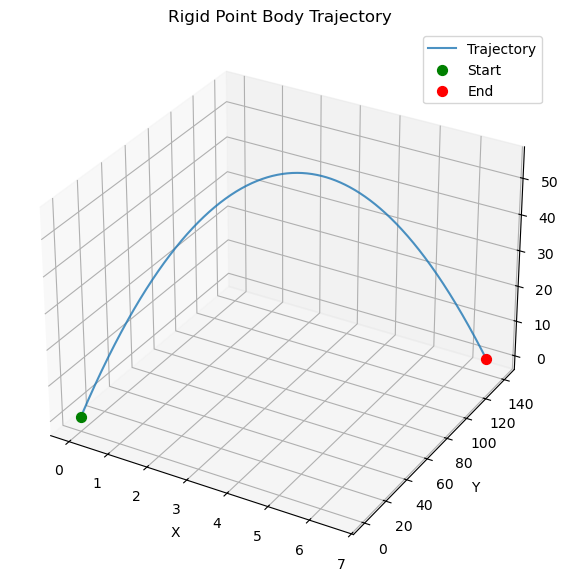

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


def visualize_trajectory(pos_data):
    """
    Visualizes a 3D trajectory given an array of positions.

    Args:
        pos_data: Numpy array-like object containing trajectory data.
                  Can be shape (N, 3) or (3, N).
    """
    # Convert input to numpy array for consistent handling
    data = np.array(pos_data)

    # Determine the layout of the data (N, 3) vs (3, N)
    # We assume the larger dimension is the number of time steps (N)
    if data.shape[0] == 3 and data.shape[1] > 3:
        # Shape is (3, N): x, y, z are rows
        x, y, z = data
    else:
        # Shape is (N, 3): x, y, z are columns
        # This is the standard output for many physics simulations
        if data.shape[1] != 3:
            print(f"Warning: Data shape {data.shape} might be interpreted incorrectly.")
        x = data[:, 0]
        y = data[:, 1]
        z = data[:, 2]

    # Create the plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Plot the trajectory line
    ax.plot(x, y, z, label="Trajectory", linewidth=1.5, alpha=0.8)

    # Mark the start (Green) and end (Red) points
    ax.scatter(x[0], y[0], z[0], color="green", s=50, label="Start")
    ax.scatter(x[-1], y[-1], z[-1], color="red", s=50, label="End")

    # Labels and styling
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Rigid Point Body Trajectory")
    ax.legend()

    plt.show()


# Check if 'positions' exists in the current scope (from your notebook)
# If not, create dummy data for demonstration.
try:
    visualize_trajectory(positions)
except NameError:
    print("'positions' variable not found. Generating dummy spiral data...")
    t = np.linspace(0, 20, 500)
    # Create a spiral trajectory: (N, 3)
    dummy_positions = np.column_stack((np.cos(t), np.sin(t), t))
    visualize_trajectory(dummy_positions)

## 10. Inheritance: Specializing Physics

**Inheritance** allows a new class to adopt the physics of an existing one.
Why rewrite motion code for a `Planet` if `Body` already has it?

* **Parent Class:** `Body` (Mass, Position)
* **Child Class:** `Planet` (Gravity, Atmosphere)
* Promotes code reuse and logical hierarchy.

## 11. Polymorphism: Universal Simulation Loop

You can create a list containing mixed celestial types: `stars`, `planets`, and `asteroids`.
If they all have an `update()` method, the main loop handles them uniformly.

In [12]:
# Conceptual Code
# bodies = [sun, earth, mars, comet]
# for b in bodies:
#     b.update(dt)  
#     # Works regardless of type!

## 12. Composition: Building Systems

A `SolarSystem` object is **composed** of many `Body` objects.

* The `SolarSystem` manages global interactions (Gravity pairs).
* The `Body` manages local state (Position update).
* Separates "System Dynamics" from "Object Properties".

In [13]:
import matplotlib.pyplot as plt


class Body:
    def __init__(self, mass, position, velocity, name="", color="black"):
        self.mass = float(mass)
        self.pos = position if isinstance(position, Vector) else Vector(*position)
        self.vel = velocity if isinstance(velocity, Vector) else Vector(*velocity)
        self.name = name
        self.color = color

        # Store trajectory history for plotting
        self.path = [self.pos]

    def apply_force(self, force, dt):
        """
        Updates velocity based on Force.
        F = ma  ->  a = F / m
        v_new = v_old + a * dt
        """
        acceleration = force / self.mass
        self.vel = self.vel + acceleration * dt

    def move(self, dt):
        """
        Updates position based on Velocity.
        x_new = x_old + v * dt
        """
        self.pos = self.pos + self.vel * dt
        self.path.append(self.pos)


class SolarSystem:
    def __init__(self, G=1.0):
        self.bodies = []
        self.G = G

    def add_body(self, body):
        self.bodies.append(body)

    def step(self, dt):
        """
        Performs one time step of the simulation using Symplectic Euler.
        1. Calculate all forces (System Dynamics).
        2. Update all velocities.
        3. Update all positions.
        """
        # Dictionary to store the net force on each body for this step
        net_forces = {body: Vector(0, 0, 0) for body in self.bodies}

        # Calculate Gravity Pairs (N-body interaction)
        for i, body_a in enumerate(self.bodies):
            for j, body_b in enumerate(self.bodies):
                if i == j:
                    continue  # Don't calculate gravity on self

                # Vector pointing from A to B
                r_vec = body_b.pos - body_a.pos
                r_mag = r_vec.norm()

                # Softening parameter or check to avoid division by zero
                if r_mag == 0:
                    continue

                # F_gravity magnitude = (G * m1 * m2) / r^2
                # We multiply by r_vec/r_mag (direction) -> (G * m1 * m2) / r^3 * r_vec
                force_mag = (self.G * body_a.mass * body_b.mass) / (r_mag**3)
                force_on_a = r_vec * force_mag

                # Accumulate force
                net_forces[body_a] = net_forces[body_a] + force_on_a

        # Apply forces and move bodies (Symplectic Euler)
        for body in self.bodies:
            body.apply_force(net_forces[body], dt)  # Update Velocity
            body.move(dt)  # Update Position

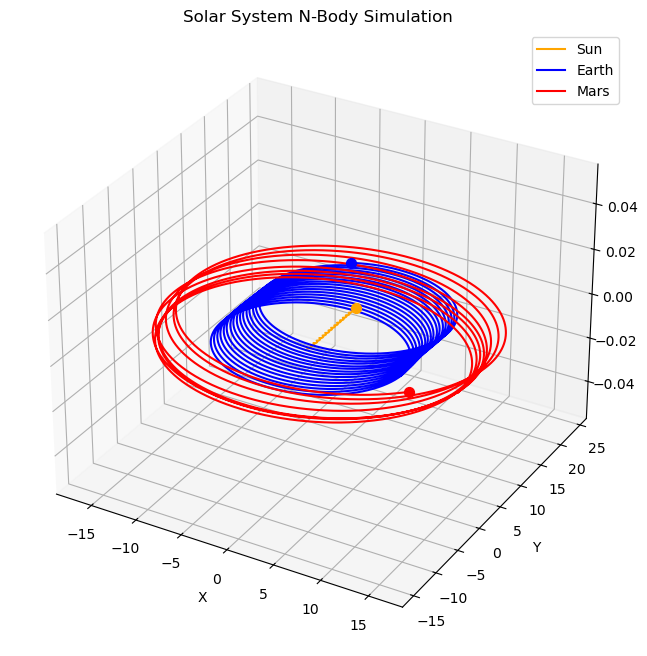

In [14]:
# Create the System
solar_system = SolarSystem(G=1.0)

# Define Bodies (Units: Arbitrary for demo)
# Sun: Heavy, stationary at center
sun = Body(
    mass=1000, position=[0, 0, 0], velocity=[0, 0, 0], name="Sun", color="orange"
)

# Earth: Starts at x=10, circular velocity v = sqrt(GM/r) = sqrt(1000/10) = 10
earth = Body(
    mass=10, position=[10, 0, 0], velocity=[0, 10, 0], name="Earth", color="blue"
)

# Mars: Starts at x=16, v = sqrt(1000/16) = 7.9
mars = Body(mass=1, position=[16, 0, 0], velocity=[0, 7.9, 0], name="Mars", color="red")

solar_system.add_body(sun)
solar_system.add_body(earth)
solar_system.add_body(mars)

# Run Simulation
dt = 0.01
steps = 10000
for _ in range(steps):
    solar_system.step(dt)

# --- Visualization ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

for body in solar_system.bodies:
    # Extract x, y, z from path history
    xs = [p.x for p in body.path]
    ys = [p.y for p in body.path]
    zs = [p.z for p in body.path]

    ax.plot(xs, ys, zs, label=body.name, color=body.color)
    ax.scatter(xs[-1], ys[-1], zs[-1], color=body.color, s=50)  # Current pos

ax.set_title("Solar System N-Body Simulation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
plt.show()

## 13. Encapsulation: Protecting Physical Laws

We can prevent non-physical states (like negative mass) by hiding data.
Use python properties to enforce constraints.

In [15]:
class Body:
    def __init__(
        self,
        mass,
        position=Vector(0, 0, 0),
        velocity=Vector(0, 0, 0),
        name="",
        color="black",
    ):
        self.mass = float(mass)
        self.pos = position if isinstance(position, Vector) else Vector(*position)
        self.vel = velocity if isinstance(velocity, Vector) else Vector(*velocity)
        self.name = name
        self.color = color

        # Store trajectory history for plotting
        self.path = [self.pos]

    @property
    def mass(self):
        return self._mass

    @mass.setter
    def mass(self, val):
        if val <= 0:
            raise ValueError("Mass must be greater than 0!")
        self._mass = val

    def apply_force(self, force, dt):
        """
        Updates velocity based on Force.
        F = ma  ->  a = F / m
        v_new = v_old + a * dt
        """
        acceleration = force / self.mass
        self.vel = self.vel + acceleration * dt

    def move(self, dt):
        """
        Updates position based on Velocity.
        x_new = x_old + v * dt
        """
        self.pos = self.pos + self.vel * dt
        self.path.append(self.pos)

In [16]:
Body(-1)

ValueError: Mass must be greater than 0!

## 17. Case Study: Orbital Stability

### The Code vs. The Cosmos
Why does OOP matter for numerical accuracy? It allows us to encapsulate the **integration method** separately from the physics.

Let's simulate a planet orbiting a star using two different methods to see why naive coding fails.

**Spoiler: One of these methods destroys the universe.**

## 18. The Naive Approach: Euler Method

**Forward Euler Integration:**
$x_{i+1} = x_i + v_i \Delta t$
$v_{i+1} = v_i + a_i \Delta t$

Using the *old* velocity to update position introduces a systematic error that grows over time.

In [ ]:
class EulerOrbit:
    def __init__(self, position, velocity, G=1.0, M=1.0, dt=0.01):
        """
        Initialize the simulation using Vector objects.
        """
        # Ensure inputs are Vector objects
        self.r = position if isinstance(position, Vector) else Vector(*position)
        self.v = velocity if isinstance(velocity, Vector) else Vector(*velocity)
        self.G = G
        self.M = M
        self.dt = dt
        self.a = self.get_acceleration(self.r)

        # Storage for history
        self.position_history = [self.r]
        self.energy_history = [self.calculate_total_energy()]

    def get_acceleration(self, r):
        """Calculates acceleration: a = -GM * r / |r|^3 using Vector math."""
        r_mag = r.norm()
        # Avoid division by zero
        if r_mag == 0:
            return Vector(0, 0, 0)

        factor = -(self.G * self.M) / (r_mag**3)
        return r * factor  # Vector scalar multiplication

    def calculate_total_energy(self):
        """Calculates specific orbital energy."""
        v_sq = self.v.norm() ** 2
        r_mag = self.r.norm()

        ke = 0.5 * v_sq
        pe = -(self.G * self.M) / r_mag
        return ke + pe

    def step(self):
        """Performs one step of Explicit Euler integration."""
        self.a = self.get_acceleration(self.r)

        # Explicit Euler using Vector overloading:
        self.r = self.r + self.v * self.dt
        self.v = self.v + self.a * self.dt
        # Store state
        self.position_history.append(self.r)
        self.energy_history.append(self.calculate_total_energy())

    def integrate(self, num_steps):
        for _ in range(num_steps):
            self.step()
        return self.position_history

## 19. The Consequence: Energy Drift

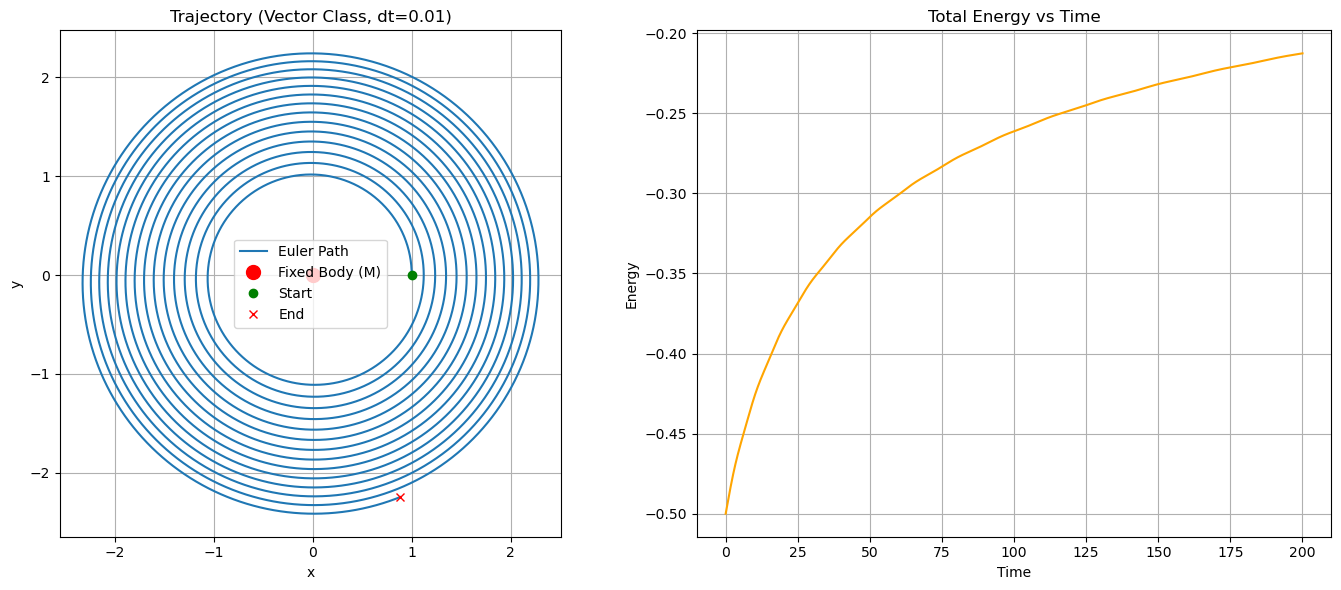

In [ ]:
# --- Simulation and Visualization ---

# Parameters
r0 = Vector(1.0, 0.0, 0.0)
v0 = Vector(0.0, 1.0, 0.0)
dt = 0.01  # /10 <--- try smaller steps
steps = 20000

# Run Simulation
sim = EulerOrbit(position=r0, velocity=v0, G=1.0, M=1.0, dt=dt)
history = sim.integrate(steps)

# Extract data for plotting (convert Vectors back to lists of coordinates)
x_vals = [p.x for p in history]
y_vals = [p.y for p in history]
energies = sim.energy_history

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Trajectory
ax1.plot(x_vals, y_vals, label="Euler Path")
ax1.plot(0, 0, "ro", markersize=10, label="Fixed Body (M)")
ax1.plot(x_vals[0], y_vals[0], "go", label="Start")
ax1.plot(x_vals[-1], y_vals[-1], "rx", label="End")
ax1.set_aspect("equal")
ax1.set_title(f"Trajectory (Vector Class, dt={dt})")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid(True)
ax1.legend()

# Energy
time_axis = [i * dt for i in range(len(energies))]
ax2.plot(time_axis, energies, color="orange")
ax2.set_title("Total Energy vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Energy")
ax2.grid(True)

plt.tight_layout()
plt.show()

In the Euler method, the error doesn't average out; it accumulates.
* The planet systematically steps "outwards" more than it should.
* Total Energy ($E = T + U$) increases over time.
* The orbit spirals away to infinity.
* **Physical Reality Violated.**

## 20. The Fix: Symplectic Integrator (Euler-Cromer)

We make a single, subtle change: use the **new** velocity to update the position.

$v_{i+1} = v_i + a_i \Delta t$

$x_{i+1} = x_i + \mathbf{v_{i+1}} \Delta t$

This method is **Symplectic**: it preserves the phase-space area, meaning energy oscillates boundedly but does not drift.

In [ ]:
class SymplecticEulerOrbit(EulerOrbit):
    def __init__(self, position, velocity, G=1.0, M=1.0, dt=0.01):
        super().__init__(position, velocity, G, M, dt)

    # ... assumes standard properties exist ...
    def step(self):
        """Performs one step of Explicit Euler integration."""
        # Update velocity FIRST
        self.v = self.v + self.a * self.dt

        # Update Position using NEW velocity
        self.r = self.r + self.v * self.dt

        # Recalculate forces
        self.a = self.get_acceleration(self.r)

        # Store state
        self.position_history.append(self.r)
        self.energy_history.append(self.calculate_total_energy())

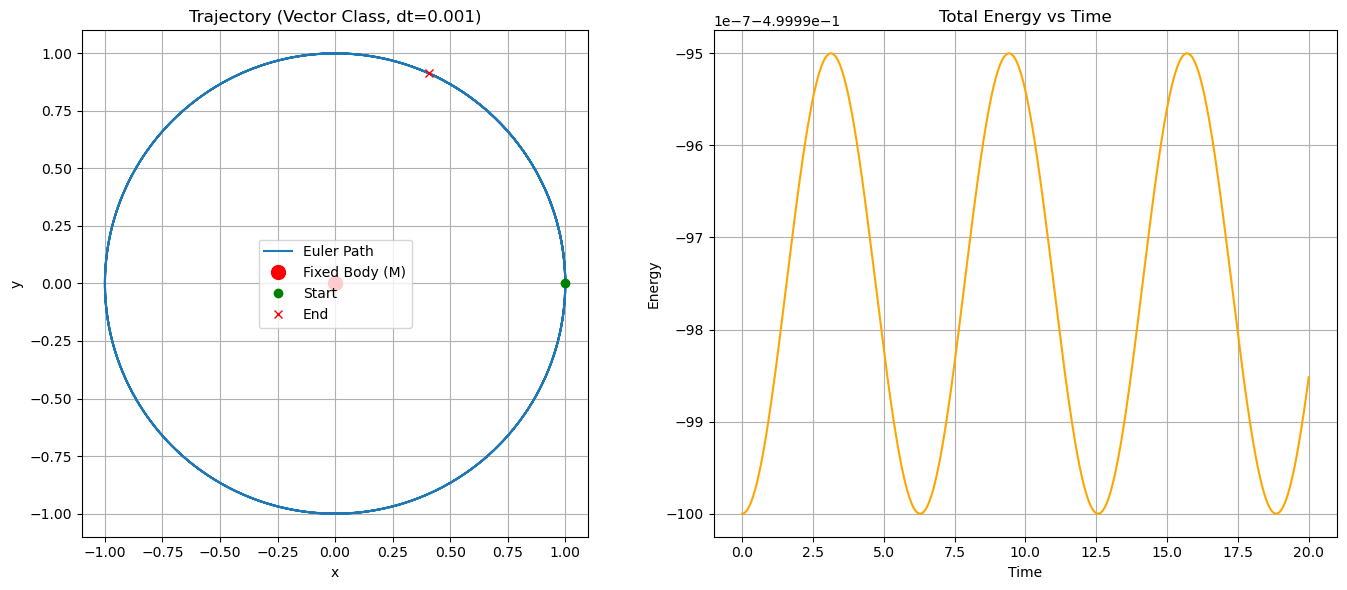

In [ ]:
# --- Simulation and Visualization ---

# Parameters
r0 = Vector(1.0, 0.0, 0.0)
v0 = Vector(0.0, 1.0, 0.0)
dt = 0.001  # /10 <--- try smaller steps
steps = 20000

# Run Simulation
sim = SymplecticEulerOrbit(position=r0, velocity=v0, G=1.0, M=1.0, dt=dt)
history = sim.integrate(steps)

# Extract data for plotting (convert Vectors back to lists of coordinates)
x_vals = [p.x for p in history]
y_vals = [p.y for p in history]
energies = sim.energy_history

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Trajectory
ax1.plot(x_vals, y_vals, label="Euler Path")
ax1.plot(0, 0, "ro", markersize=10, label="Fixed Body (M)")
ax1.plot(x_vals[0], y_vals[0], "go", label="Start")
ax1.plot(x_vals[-1], y_vals[-1], "rx", label="End")
ax1.set_aspect("equal")
ax1.set_title(f"Trajectory (Vector Class, dt={dt})")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid(True)
ax1.legend()

# Energy
time_axis = [i * dt for i in range(len(energies))]
ax2.plot(time_axis, energies, color="orange")
ax2.set_title("Total Energy vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Energy")
ax2.grid(True)

plt.tight_layout()
plt.show()

## 21. Comparison Results

* **Euler:** Energy grows linearly. The planet escapes the solar system in a few thousand steps.
* **Symplectic:** Energy stays constant (oscillates slightly due to discretization). The orbit is stable for billions of steps.

**Lesson:** Your choice of Class Method dictates physical validity.

## 22. Vectorization & Broadcasting

**The Python Loop Problem:** Explicit `for` loops in Python are slow due to type-checking overhead.

**The Solution:** Array Operations.
* **Broadcasting:** Applying an operation to an entire array at once.
* **SIMD:** NumPy uses Low-level C optimization.

In [ ]:
import time
N = 1_000_000
arr = np.random.rand(N)

# Slow Loop
t0 = time.time()
res = [x * 2 for x in arr]
print(f"Loop: {time.time()-t0:.4f}s")

# Fast Vectorization
t0 = time.time()
res = arr * 2 # Broadcasting
print(f"Vectorized: {time.time()-t0:.4f}s")

Loop: 0.0966s
Vectorized: 0.0090s


## 23. Performance: Python vs. C++

**The "Pure Python" Trap**
Creating 1,000,000 `Asteroid` objects is slow.

**The Solution**
Use OOP for structure (System, IO, Setup) but use **NumPy arrays** for the state.
Instead of `[Particle() for _ in range(N)]`, use a `ParticleSwarm` class holding `self.pos = np.zeros((N,3))`.

## 24. Discussion Questions

1. Why does the Euler-Cromer method conserve energy better despite being only 1st order accurate? (Hint: Phase Space)
2. How would you structure a "Spring" class that connects two "Body" objects to avoid numerical explosions?
3. In a collision system, should the `Ball` handle the collision logic, or should a `CollisionManager` class do it?